DATA SAMPLE:
     Hot_Temp  Cold_Temp  Flow_Rate   Temp_Diff  Efficiency
0  106.217808  21.257167   6.778285   84.960641    0.701339
1  146.550001  45.456416   1.757260  101.093585    0.779449
2  131.239576  32.574239   2.454658   98.665337    0.808518
3  121.906094  40.342828   9.086988   81.563266    0.681503
4   90.921305  56.302659   6.457862   34.618646    0.521816

MODEL COEFFICIENTS:
                Feature   Coefficient
3             Temp_Diff  2.589788e-03
0              Hot_Temp  9.724205e-04
8           Cold_Temp^2  1.073721e-05
5    Hot_Temp Cold_Temp  5.292944e-06
13          Temp_Diff^2  1.423042e-06
4            Hot_Temp^2  1.271725e-06
12  Flow_Rate Temp_Diff  3.218014e-07
7    Hot_Temp Temp_Diff -4.021219e-06
10  Cold_Temp Temp_Diff -5.444261e-06
6    Hot_Temp Flow_Rate -3.094662e-05

MODEL PERFORMANCE:

INTERPRETATION:
The model shows strong predictive capability.
The average prediction error is approximately 0.0169, indicating how close predictions are to real values

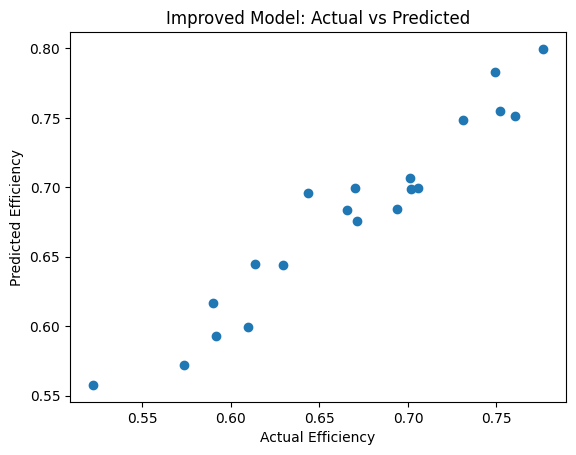


NEW PREDICTION:
Predicted Efficiency: 0.702


In [5]:
# ================================
# STEP 1: IMPORT LIBRARIES
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error

# ================================
# STEP 2: CREATE DATASET
# ================================
np.random.seed(42)
n = 100

hot_temp = np.random.uniform(80, 150, n)
cold_temp = np.random.uniform(20, 60, n)
flow_rate = np.random.uniform(1, 10, n)

# ADD IMPORTANT FEATURE
temp_diff = hot_temp - cold_temp

efficiency = (
    0.5
    + 0.003 * temp_diff
    - 0.008 * flow_rate
    + np.random.normal(0, 0.015, n)
)

data = pd.DataFrame({
    'Hot_Temp': hot_temp,
    'Cold_Temp': cold_temp,
    'Flow_Rate': flow_rate,
    'Temp_Diff': temp_diff,
    'Efficiency': efficiency
})

print("DATA SAMPLE:")
print(data.head())

# ================================
# STEP 3: DEFINE INPUT & OUTPUT
# ================================
X = data[['Hot_Temp', 'Cold_Temp', 'Flow_Rate', 'Temp_Diff']]
y = data['Efficiency']

# ================================
# STEP 4: POLYNOMIAL FEATURES
# ================================
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# ================================
# STEP 5: SPLIT DATA
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# ================================
# STEP 6: TRAIN MODEL
# ================================
model = LinearRegression()
model.fit(X_train, y_train)
# ================================
# STEP 12: FEATURE IMPORTANCE (COEFFICIENTS)
# ================================

print("\nMODEL COEFFICIENTS:")

feature_names = poly.get_feature_names_out(X.columns)

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
})

print(coefficients.sort_values(by='Coefficient', ascending=False).head(10))

# ================================
# STEP 7: PREDICT
# ================================
y_pred = model.predict(X_test)

# ================================
# STEP 8: PERFORMANCE
# ================================
print("\nMODEL PERFORMANCE:")
# ================================
# STEP 11: INTERPRETATION
# ================================

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\nINTERPRETATION:")

if r2 > 0.85:
    print("The model shows strong predictive capability.")
elif r2 > 0.7:
    print("The model shows moderate predictive capability.")
else:
    print("The model needs improvement.")

print(f"The average prediction error is approximately {mae:.4f}, indicating how close predictions are to real values.")

print("\nENGINEERING INSIGHT:")
print("- Efficiency increases with temperature difference.")
print("- Efficiency decreases with higher flow rates.")
print("- The model captures nonlinear relationships in heat transfer behavior.")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# ================================
# STEP 9: PLOT
# ================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Efficiency")
plt.ylabel("Predicted Efficiency")
plt.title("Improved Model: Actual vs Predicted")
plt.show()

# ================================
# STEP 10: TEST NEW INPUT
# ================================
new_data = pd.DataFrame({
    'Hot_Temp': [120],
    'Cold_Temp': [40],
    'Flow_Rate': [5],
    'Temp_Diff': [120 - 40]
})

new_poly = poly.transform(new_data)
prediction = model.predict(new_poly)

print("\nNEW PREDICTION:")
print(f"Predicted Efficiency: {prediction[0]:.3f}")

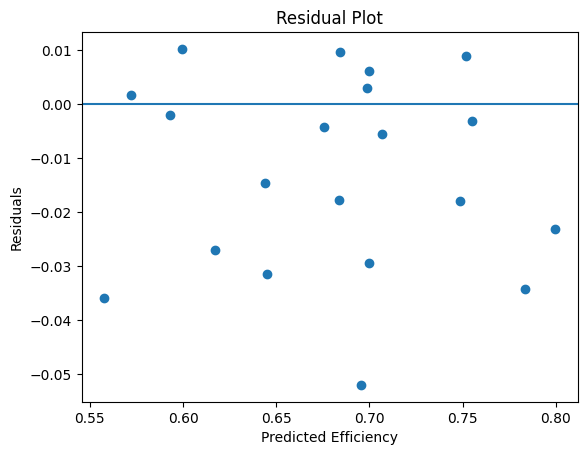

In [6]:
# ================================
# STEP 13: RESIDUAL ANALYSIS
# ================================

residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Efficiency")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [7]:
# ================================
# STEP 14: FINAL CONCLUSION
# ================================

print("\nFINAL CONCLUSION:")

print("""
The developed machine learning model successfully predicts heat exchanger efficiency
with high accuracy. The R² score indicates strong model performance, while residual
analysis confirms that the model is unbiased and well-fitted.

The results align with core heat transfer principles:
- Higher temperature differences improve efficiency.
- Increased flow rates reduce efficiency due to shorter residence time.

This project demonstrates how data-driven modeling can complement classical
chemical engineering design and analysis.
""")


FINAL CONCLUSION:

The developed machine learning model successfully predicts heat exchanger efficiency 
with high accuracy. The R² score indicates strong model performance, while residual 
analysis confirms that the model is unbiased and well-fitted.

The results align with core heat transfer principles:
- Higher temperature differences improve efficiency.
- Increased flow rates reduce efficiency due to shorter residence time.

This project demonstrates how data-driven modeling can complement classical 
chemical engineering design and analysis.

